# Task 1: Data Cleaning & Exploratory Data Analysis
**Dataset:** Telco Customer Churn | **Goal:** Understand, clean, and extract business insights

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

df = pd.read_csv("../data/telco_churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 1: Check Data Quality

In [4]:
print("**Data Types")
print(df.dtypes)
print("\n**Missing Values")
print(df.isnull().sum())
print("\n**Unique Values in Object Columns")
for col in df.select_dtypes("object").columns:
    print(f"  {col}: {df[col].nunique()} unique")

**Data Types
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

**Missing Values
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBillin

In [5]:
# TotalCharges has spaces — real-world dirty data!
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
missing_idx = df["TotalCharges"].isnull()
print(f"Missing TotalCharges: {missing_idx.sum()} rows (all have tenure=0)")
print(df[missing_idx][["customerID","tenure","MonthlyCharges","TotalCharges"]])
# Justification: New customers have 0 tenure, fill with their monthly charge
df["TotalCharges"].fillna(df["MonthlyCharges"], inplace=True)
print("Filled with MonthlyCharges (just joined)")

Missing TotalCharges: 11 rows (all have tenure=0)
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN
Filled with MonthlyCharges (just joined)


## Step 2: Outlier Detection (IQR Method)

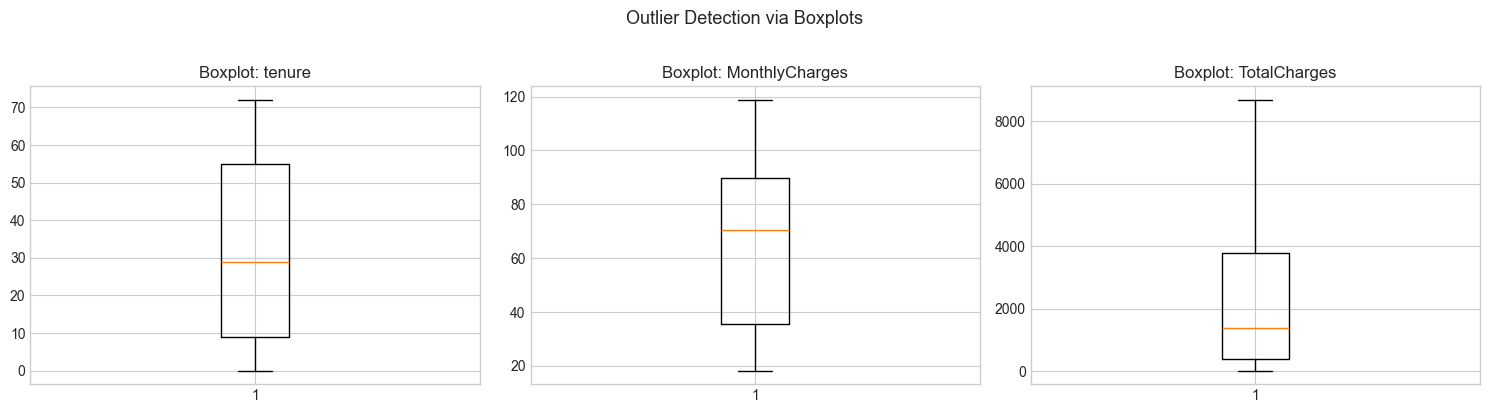

tenure: 0 outliers -> KEEPING (valid telecom billing data)
MonthlyCharges: 0 outliers -> KEEPING (valid telecom billing data)
TotalCharges: 0 outliers -> KEEPING (valid telecom billing data)


In [6]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(f"Boxplot: {col}")
plt.suptitle("Outlier Detection via Boxplots", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("../slides/boxplots.png", dpi=100, bbox_inches="tight")
plt.show()

for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outs = df[(df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)]
    print(f"{col}: {len(outs)} outliers -> KEEPING (valid telecom billing data)")

# No extreme outliers in tenure or MonthlyCharges. TotalCharges has some high-value customers

## Step 3: Feature Distribution Plots

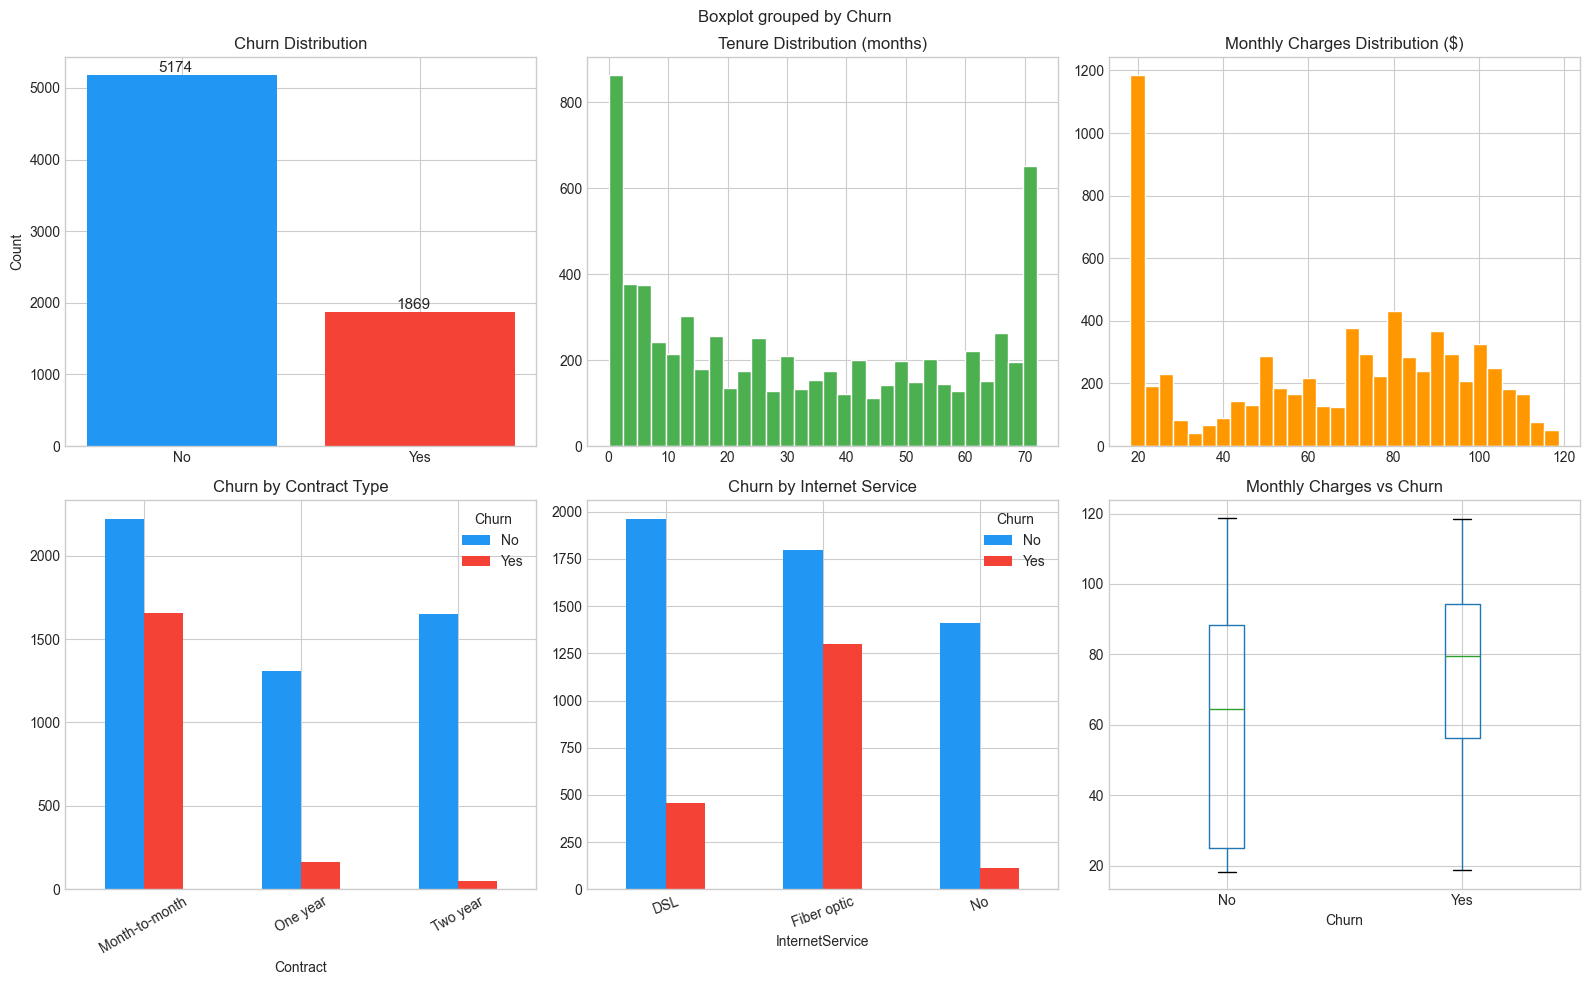

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# 1. Churn distribution
counts = df["Churn"].value_counts()
axes[0].bar(counts.index, counts.values, color=["#2196F3","#F44336"])
axes[0].set_title("Churn Distribution"); axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x()+0.3, bar.get_height()+50, str(val), fontsize=11)

# 2. Tenure histogram
axes[1].hist(df["tenure"], bins=30, color="#4CAF50", edgecolor="white")
axes[1].set_title("Tenure Distribution (months)")

# 3. Monthly Charges histogram
axes[2].hist(df["MonthlyCharges"], bins=30, color="#FF9800", edgecolor="white")
axes[2].set_title("Monthly Charges Distribution ($)")

# 4. Churn by Contract
pd.crosstab(df["Contract"], df["Churn"]).plot(kind="bar", ax=axes[3], color=["#2196F3","#F44336"])
axes[3].set_title("Churn by Contract Type"); axes[3].tick_params(axis="x", rotation=30)

# 5. Churn by Internet Service
pd.crosstab(df["InternetService"], df["Churn"]).plot(kind="bar", ax=axes[4], color=["#2196F3","#F44336"])
axes[4].set_title("Churn by Internet Service"); axes[4].tick_params(axis="x", rotation=20)

# 6. Monthly Charges vs Churn (boxplot)
df.boxplot(column="MonthlyCharges", by="Churn", ax=axes[5])
axes[5].set_title("Monthly Charges vs Churn")

plt.tight_layout()
plt.savefig("../slides/distributions.png", dpi=100, bbox_inches="tight")
plt.show()

* Graph 1: Churn Distribution Bar Chart :  
1) 5,174 stayed (No) vs 1,869 left (Yes) 
2) 26.5% churn rate. This is an IMBALANCED dataset (74%/26% split)
3) 1 in 4 customers leaves. Industry avg is 15-20%. We are above benchmark.

* Graph 2: Tenure Histogram 
1) WHAT IT SHOWS: How long customers have been with the company (in months) 
2) Two peaks — one near 0 months, another near 70 months.
3) Two types of customers — new joiners and long-term loyalists. Few in the middle
4) The 'missing middle' — customers are either new (high churn risk) or very old (loyal). The middle period is the battle zone.
Solution : Focus retention campaigns on 12-36 month tenure group — before they decide to leave

* Graph 3: Monthly Charges Distribution
1) peak at $20 (basic users) and $80-120 (premium users)
Problem : Premium users ($70+) churn more because they feel they're not getting value for money. They pay a lot but aren't locked in.

* Graph 4: Churn by Contract Type (Grouped Bar Chart)
1) Month-to-month customers have zero financial switching cost. They can leave instantly.
2) 'Contract type was the #1 feature in my model — confirmed by both 
the bar chart and SHAP values.'



## Step 4: Correlation Heatmap

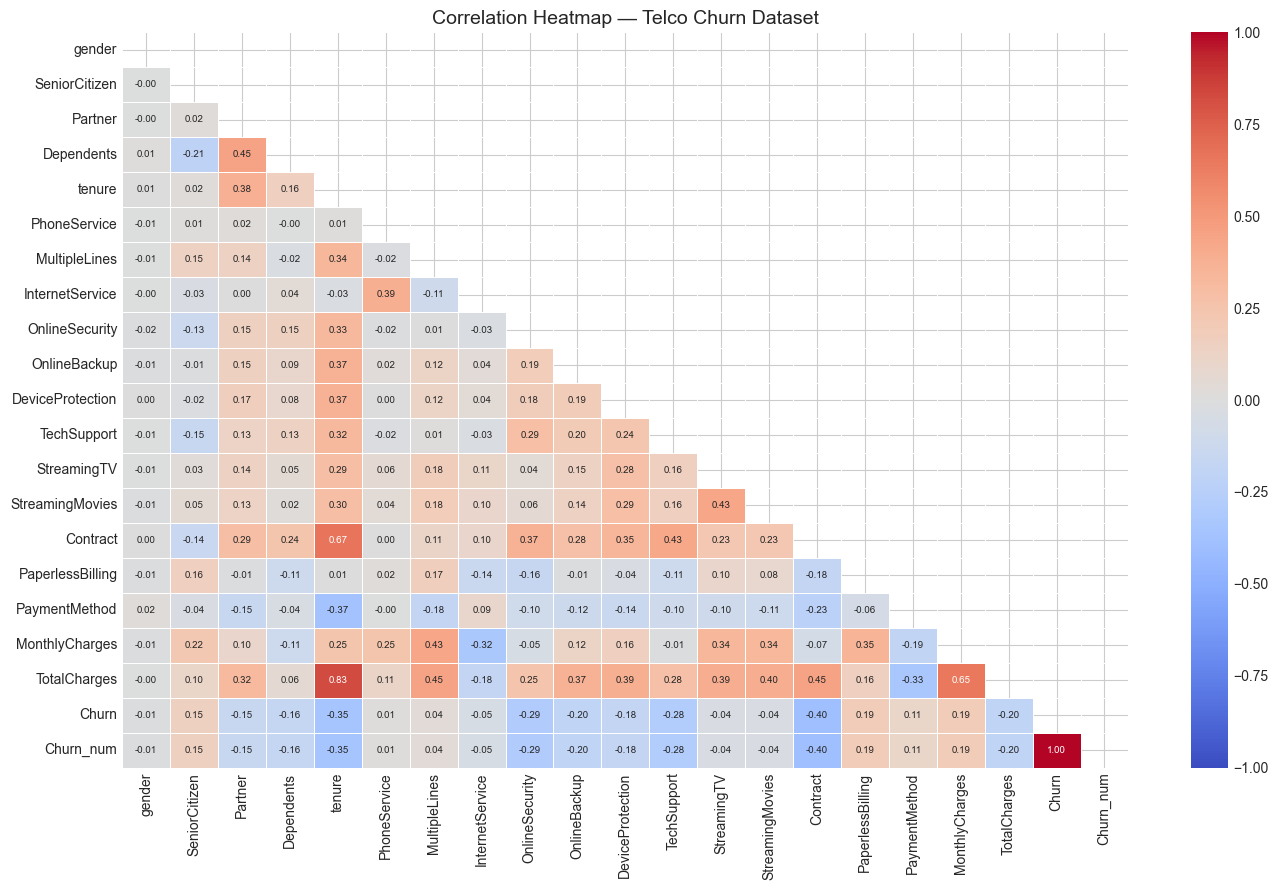

In [8]:
from sklearn.preprocessing import LabelEncoder
df_c = df.copy()
df_c["Churn_num"] = (df_c["Churn"] == "Yes").astype(int)
le = LabelEncoder()
for col in df_c.select_dtypes("object").columns:
    df_c[col] = le.fit_transform(df_c[col])
df_c = df_c.drop("customerID", axis=1, errors="ignore")

plt.figure(figsize=(14, 9))
corr = df_c.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", mask=mask,
            cmap="coolwarm", linewidths=0.5, vmin=-1, vmax=1, annot_kws={"size":7})
plt.title("Correlation Heatmap — Telco Churn Dataset", fontsize=14)
plt.tight_layout()
plt.savefig("../slides/heatmap.png", dpi=100, bbox_inches="tight")
plt.show()

* Correlation Heatmap :
1) tenure and TotalCharges have correlation ~0.83. EXPECTED — longer customers naturally accumulate more total charges. 
2) MonthlyCharges and TotalCharges = 0.65 correlation. Customers paying more accumulate faster.
3) Churn_num (target) correlates most negatively with tenure — long-term customers rarely churn.

## Step 5: 6 Business Insights

| Insight | Data | Business Meaning | Actionable Strategy |
|--------|------|-----------------|---------------------|
| **High Overall Churn Rate** | 26.5% (Industry avg: 15–20%) | One in four customers is leaving. Higher than competitors → revenue loss. | Focus on retention strategies. Even 1% reduction = significant monthly savings. |
| **Contract Type Impact** | Month-to-month: 42.7% vs 2-year: 2.8% | Customers without commitment leave easily. Strongest churn predictor. | Push long-term contracts via discounts, loyalty benefits. |
| **Tenure Effect** | Churned: 18 months vs Retained: 37.6 months | Customers leave early. First year is critical. | Improve onboarding & engagement in first 12 months. |
| **Fiber Optic Churn** | 41.9% churn | Premium users are most dissatisfied → value mismatch. | Improve service quality, reliability, or pricing justification. |
| **Payment Method Risk** | Electronic check: 45.3% vs Auto-pay: 15–17% | Manual payers are less committed. | Incentivize auto-pay adoption (discounts, rewards). |
| **Senior Citizen Churn** | 41.7% vs 23.6% | Seniors struggle with complexity (billing, plans). | Introduce simplified plans, better support, paper billing. |